In [ ]:
import math
import random

# Define possible tactical actions
ACTIONS = ['FORWARD', 'TURN_LEFT', 'TURN_RIGHT', 'POST_STALL_FLIP']

class FighterJet:
    def __init__(self, name, x, y, heading, energy):
        self.name = name
        self.x = x
        self.y = y
        self.heading = heading  # 0 to 315 degrees (8-way grid movement)
        self.energy = energy    # Represents airspeed and maneuverability potential
        self.is_stalled = False

    def clone(self):
        # Useful for search algorithms that need to evaluate future states
        return FighterJet(self.name, self.x, self.y, self.heading, self.energy)

    def apply_action(self, action):
        """Updates the jet's state based on the chosen maneuver."""
        if self.is_stalled:
            self.energy += 10 # Slowly regain energy
            if self.energy > 30:
                self.is_stalled = False
            return # Cannot maneuver while stalled

        if action == 'FORWARD':
            self.energy = min(100, self.energy + 5) # Gain energy by flying straight
            self._move_forward()

        elif action == 'TURN_LEFT':
            self.energy -= 10 # Turning bleeds energy
            self.heading = (self.heading - 45) % 360
            self._move_forward()

        elif action == 'TURN_RIGHT':
            self.energy -= 10
            self.heading = (self.heading + 45) % 360
            self._move_forward()

        elif action == 'POST_STALL_FLIP':
            # The extreme thrust-vectoring maneuver
            self.energy -= 60 # Massive energy cost
            self.heading = (self.heading + 180) % 360 # Instant 180 flip
            # Notice we DO NOT move forward; the jet is practically hovering
            if self.energy <= 0:
                self.energy = 0
                self.is_stalled = True

    def _move_forward(self):
        # Basic trigonometry to update grid position based on heading
        rad = math.radians(self.heading)
        self.x += round(math.cos(rad))
        self.y += round(math.sin(rad))

    def has_lock_on(self, target):
        """Checks if the target is directly in front of this jet."""
        dx = target.x - self.x
        dy = target.y - self.y
        angle_to_target = (math.degrees(math.atan2(dy, dx)) + 360) % 360

        # Lock-on achieved if target is within a 45-degree cone in front
        angle_diff = abs(self.heading - angle_to_target)
        if angle_diff > 180:
            angle_diff = 360 - angle_diff

        distance = math.hypot(dx, dy)
        return angle_diff <= 22.5 and distance <= 5

In [ ]:
class CombatAI:
    def __init__(self, ai_jet):
        self.jet = ai_jet

    def evaluate_state(self, simulated_jet, target_jet):
        """The heuristic function: scores the tactical viability of a state."""
        score = 0

        # 1. Reward achieving a lock-on
        if simulated_jet.has_lock_on(target_jet):
            score += 1000

        # 2. Penalize being locked onto by the enemy
        if target_jet.has_lock_on(simulated_jet):
            score -= 2000

        # 3. Reward maintaining high energy
        score += simulated_jet.energy * 2

        # 4. Heavy penalty for stalling out (vulnerable)
        if simulated_jet.is_stalled:
            score -= 500

        # 5. Distance optimization (want to be close, but not colliding)
        dist = math.hypot(target_jet.x - simulated_jet.x, target_jet.y - simulated_jet.y)
        if dist > 0:
            score -= dist * 5

        return score

    def choose_best_action(self, adversary):
        """One-ply search: looks one step ahead to pick the best move."""
        best_action = None
        best_score = -float('inf')

        # Simulate all possible actions
        for action in ACTIONS:
            sim_jet = self.jet.clone()
            sim_jet.apply_action(action)

            # Evaluate the resulting state
            state_score = self.evaluate_state(sim_jet, adversary)

            if state_score > best_score:
                best_score = state_score
                best_action = action

        return best_action

In [ ]:
def run_simulation():
    # Initialize the grid with our AI and a dummy adversary
    ai_jet = FighterJet(name="Su-57_AI", x=0, y=0, heading=90, energy=80)
    adversary = FighterJet(name="Target_Drone", x=0, y=4, heading=90, energy=50)

    ai_controller = CombatAI(ai_jet)

    print("--- Starting Combat Simulation ---")

    for turn in range(1, 6):
        print(f"\n[Turn {turn}]")
        print(f"AI State: Pos({ai_jet.x}, {ai_jet.y}), Heading: {ai_jet.heading}°, Energy: {ai_jet.energy}")
        print(f"Adversary State: Pos({adversary.x}, {adversary.y}), Heading: {adversary.heading}°, Energy: {adversary.energy}")

        # 1. AI decides and acts
        best_move = ai_controller.choose_best_action(adversary)
        print(f">> AI chooses action: {best_move}")
        ai_jet.apply_action(best_move)

        # Check for immediate win condition
        if ai_jet.has_lock_on(adversary):
            print(">> STATUS: AI has achieved Missile Lock-On! Kill confirmed.")
            break

        # 2. Adversary acts (Simple scripted behavior: just fly straight)
        adversary.apply_action('FORWARD')

run_simulation()

--- Starting Combat Simulation ---

[Turn 1]
AI State: Pos(0, 0), Heading: 90°, Energy: 80
Adversary State: Pos(0, 4), Heading: 90°, Energy: 50
>> AI chooses action: FORWARD
>> STATUS: AI has achieved Missile Lock-On! Kill confirmed.


In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Required for Notebook/Colab rendering

def run_animated_simulation():
    # Initialize entities (assuming FighterJet and CombatAI are already defined above)
    ai_jet = FighterJet(name="Su-57_AI", x=0, y=0, heading=90, energy=80)
    adversary = FighterJet(name="Target_Drone", x=0, y=6, heading=90, energy=50)
    ai_controller = CombatAI(ai_jet)

    # Setup the plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-10, 10)
    ax.set_ylim(-2, 12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title("Autonomous Combat Logic in Post-Stall Regimes")

    # Visual markers
    ai_marker, = ax.plot([], [], 'bo', markersize=10, label="AI (Su-57)")
    adv_marker, = ax.plot([], [], 'ro', markersize=8, label="Target")

    # Text display
    status_text = ax.text(-9, 11, "", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    ax.legend(loc="lower right")

    # History for flight paths
    ai_history_x, ai_history_y = [], []
    adv_history_x, adv_history_y = [], []
    ai_path, = ax.plot([], [], 'b-', alpha=0.5)
    adv_path, = ax.plot([], [], 'r-', alpha=0.5)

    def init():
        ai_marker.set_data([], [])
        adv_marker.set_data([], [])
        return ai_marker, adv_marker, ai_path, adv_path, status_text

    def update(frame):
        # 1. AI decides and acts
        best_move = ai_controller.choose_best_action(adversary)
        ai_jet.apply_action(best_move)

        # 2. Adversary acts
        adversary.apply_action('FORWARD')

        # Update histories
        ai_history_x.append(ai_jet.x)
        ai_history_y.append(ai_jet.y)
        adv_history_x.append(adversary.x)
        adv_history_y.append(adversary.y)

        # Update visuals
        ai_marker.set_data([ai_jet.x], [ai_jet.y])
        adv_marker.set_data([adversary.x], [adversary.y])
        ai_path.set_data(ai_history_x, ai_history_y)
        adv_path.set_data(adv_history_x, adv_history_y)

        # Check for Lock-On
        lock_status = "LOCKED ON - KILL" if ai_jet.has_lock_on(adversary) else "Searching..."
        status_text.set_text(f"Turn: {frame}\nAI Energy: {ai_jet.energy}\nMove: {best_move}\nStatus: {lock_status}")

        if lock_status == "LOCKED ON - KILL":
            ai_marker.set_color('green')

        return ai_marker, adv_marker, ai_path, adv_path, status_text

    # Create the animation
    ani = FuncAnimation(fig, update, frames=10, init_func=init, blit=True, interval=500, repeat=False)

    # Close the static plot to prevent duplicate rendering in notebooks
    plt.close()

    # Return the HTML video player
    return HTML(ani.to_jshtml())

# Run the simulation and display the video player
run_animated_simulation()

Training AI for 10000 combat episodes... (This might take a few seconds)
Training Complete! Generating Heatmap...


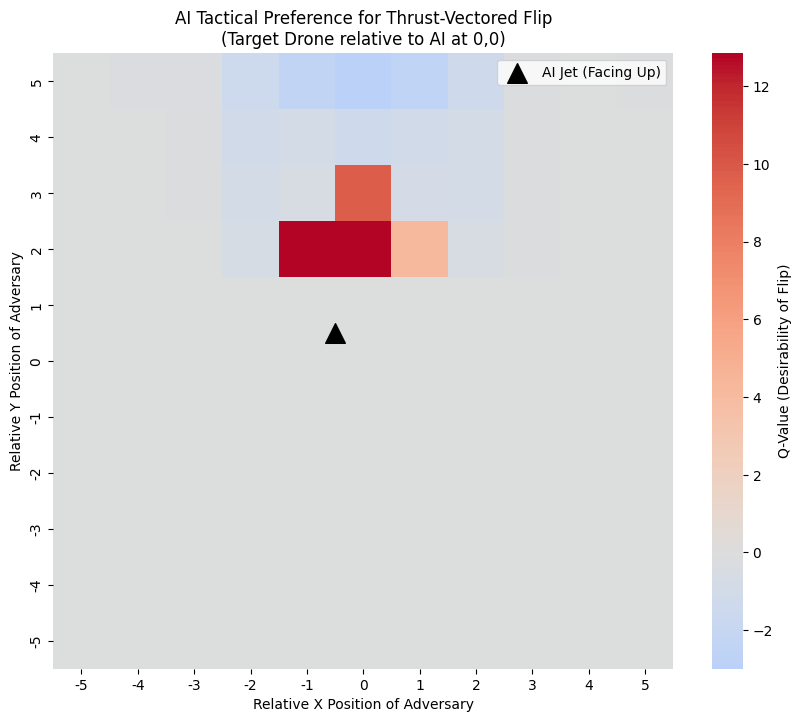

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DEFINE THE ENVIRONMENT AND PHYSICS
# ==========================================
ACTIONS = ['FORWARD', 'TURN_LEFT', 'TURN_RIGHT', 'POST_STALL_FLIP']

class FighterJet:
    def __init__(self, name, x, y, heading, energy):
        self.name = name
        self.x = x
        self.y = y
        self.heading = heading
        self.energy = energy
        self.is_stalled = False

    def clone(self):
        return FighterJet(self.name, self.x, self.y, self.heading, self.energy)

    def apply_action(self, action):
        if self.is_stalled:
            self.energy += 10
            if self.energy > 30:
                self.is_stalled = False
            return

        if action == 'FORWARD':
            self.energy = min(100, self.energy + 5)
            self._move_forward()
        elif action == 'TURN_LEFT':
            self.energy -= 10
            self.heading = (self.heading - 45) % 360
            self._move_forward()
        elif action == 'TURN_RIGHT':
            self.energy -= 10
            self.heading = (self.heading + 45) % 360
            self._move_forward()
        elif action == 'POST_STALL_FLIP':
            self.energy -= 60
            self.heading = (self.heading + 180) % 360
            if self.energy <= 0:
                self.energy = 0
                self.is_stalled = True

    def _move_forward(self):
        rad = math.radians(self.heading)
        self.x += round(math.cos(rad))
        self.y += round(math.sin(rad))

    def has_lock_on(self, target):
        dx = target.x - self.x
        dy = target.y - self.y
        angle_to_target = (math.degrees(math.atan2(dy, dx)) + 360) % 360

        angle_diff = abs(self.heading - angle_to_target)
        if angle_diff > 180:
            angle_diff = 360 - angle_diff

        distance = math.hypot(dx, dy)
        return angle_diff <= 22.5 and distance <= 5

# ==========================================
# 2. DEFINE THE AI BRAIN (Q-LEARNING)
# ==========================================
class RLCombatAI:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions
        self.q_table = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def get_state(self, ai_jet, adversary):
        dx = adversary.x - ai_jet.x
        dy = adversary.y - ai_jet.y

        grid_dx = int(np.clip(dx, -5, 5))
        grid_dy = int(np.clip(dy, -5, 5))

        energy_state = "STALLED" if ai_jet.is_stalled else "LOW"
        if ai_jet.energy > 30: energy_state = "MED"
        if ai_jet.energy > 70: energy_state = "HIGH"

        return f"{grid_dx}_{grid_dy}_{ai_jet.heading}_{energy_state}"

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)

        q_values = [self.get_q_value(state, a) for a in self.actions]
        max_q = max(q_values)
        best_actions = [a for a in self.actions if self.get_q_value(state, a) == max_q]
        return random.choice(best_actions)

    def learn(self, state, action, reward, next_state):
        predict = self.get_q_value(state, action)
        target = reward + self.gamma * max([self.get_q_value(next_state, a) for a in self.actions])
        self.q_table[(state, action)] = predict + self.alpha * (target - predict)

def calculate_reward(ai_jet, adversary):
    if ai_jet.has_lock_on(adversary):
        return 100
    if ai_jet.is_stalled:
        return -50
    return -1

# ==========================================
# 3. TRAINING LOOP & VISUALIZATION
# ==========================================
def train_and_visualize_rl():
    ai_agent = RLCombatAI(ACTIONS, alpha=0.1, gamma=0.9, epsilon=0.2)
    epochs = 10000

    print(f"Training AI for {epochs} combat episodes... (This might take a few seconds)")

    for episode in range(epochs):
        ai_jet = FighterJet(name="Su-57_AI", x=0, y=0, heading=90, energy=100)

        adv_x = random.choice([-2, -1, 0, 1, 2])
        adv_y = random.choice([2, 3, 4, 5, 6])
        adversary = FighterJet(name="Target", x=adv_x, y=adv_y, heading=90, energy=50)

        for step in range(15):
            state = ai_agent.get_state(ai_jet, adversary)
            action = ai_agent.choose_action(state)

            ai_jet.apply_action(action)
            adversary.apply_action('FORWARD')

            next_state = ai_agent.get_state(ai_jet, adversary)
            reward = calculate_reward(ai_jet, adversary)

            ai_agent.learn(state, action, reward, next_state)

            if reward == 100 or reward == -50:
                break

        if episode % 1000 == 0:
            ai_agent.epsilon = max(0.01, ai_agent.epsilon * 0.8)

    print("Training Complete! Generating Heatmap...")

    grid_size = 11
    flip_values = np.zeros((grid_size, grid_size))

    for x in range(-5, 6):
        for y in range(-5, 6):
            test_state = f"{x}_{y}_90_HIGH"
            flip_values[5-y, x+5] = ai_agent.get_q_value(test_state, 'POST_STALL_FLIP')

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(flip_values, cmap="coolwarm", center=0,
                     xticklabels=range(-5, 6), yticklabels=range(5, -6, -1),
                     annot=False, cbar_kws={'label': 'Q-Value (Desirability of Flip)'})

    plt.title("AI Tactical Preference for Thrust-Vectored Flip\n(Target Drone relative to AI at 0,0)")
    plt.xlabel("Relative X Position of Adversary")
    plt.ylabel("Relative Y Position of Adversary")

    plt.scatter([5], [5], marker='^', color='black', s=200, label="AI Jet (Facing Up)")
    plt.legend()
    plt.show()

# Run it!
train_and_visualize_rl()